In [3]:
!pip install mysql-connector-python sqlalchemy

In [4]:
!pip install mysql

In [5]:
import sys
# This ensures it installs to the ACTIVE kernel folder
!{sys.executable} -m pip install mysql-connector-python sqlalchemy

Defaulting to user installation because normal site-packages is not writeable


In [6]:
import pandas as pd
from sqlalchemy import create_engine
import mysql.connector
import glob
import os

# 1. Database Connection Details
USER = "root"      # Just 'root', no @localhost
PASSWORD = "" 
HOST = "127.0.0.1"
PORT = "3306"
DB_NAME = "Finance_fraud_loans"

In [7]:
# 2. Use 'mysqlconnector' (This is the one your image showed as 'Successfully Installed')
connection_string = f"mysql+mysqlconnector://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB_NAME}"

try:
    engine = create_engine(connection_string)
    # Simple test to see if it connects
    with engine.connect() as conn:
        print("✅ Success! Connected using mysql-connector.")
except Exception as e:
    print(f"❌ Connection failed: {e}")

✅ Success! Connected using mysql-connector.


In [17]:
import pandas as pd
import os
import glob
from sqlalchemy import create_engine

# 1. THE SPECIFIC PATH
# Note: Python uses / instead of \
folder_path = "C:/Users/bruger/Downloads/Finance/uploaded to kaggle"

# 2. Tell glob to look in that specific folder
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

print(f"📂 Searching in: {folder_path}")
print(f"🚀 Found {len(csv_files)} files to upload.")
print("-" * 30)

# 3. The Batch Upload Loop
for file in csv_files:
    # This takes 'customers.csv' and makes the table 'customers'
    table_name = os.path.splitext(os.path.basename(file))[0]
    
    print(f"Reading {table_name}...")
    
    # Read the data
    df = pd.read_csv(file)
    
    # Upload to MySQL (using the engine you successfully connected earlier)
    df.to_sql(table_name, engine, if_exists='replace', index=False)
    
    print(f"✅ Success: Table '{table_name}' created in MySQL.")

print("\n🎉 MISSION COMPLETE: All tables are now in your database!")

📂 Searching in: C:/Users/bruger/Downloads/Finance/uploaded to kaggle
🚀 Found 11 files to upload.
------------------------------
Reading accounts...
✅ Success: Table 'accounts' created in MySQL.
Reading account_statuses...
✅ Success: Table 'account_statuses' created in MySQL.
Reading account_types...
✅ Success: Table 'account_types' created in MySQL.
Reading addresses...
✅ Success: Table 'addresses' created in MySQL.
Reading branches...
✅ Success: Table 'branches' created in MySQL.
Reading customers...
✅ Success: Table 'customers' created in MySQL.
Reading customer_types...
✅ Success: Table 'customer_types' created in MySQL.
Reading loans...
✅ Success: Table 'loans' created in MySQL.
Reading loan_statuses...
✅ Success: Table 'loan_statuses' created in MySQL.
Reading transactions...
✅ Success: Table 'transactions' created in MySQL.
Reading transaction_types...
✅ Success: Table 'transaction_types' created in MySQL.

🎉 MISSION COMPLETE: All tables are now in your database!


In [8]:
import pandas as pd
customers = pd.read_sql("SELECT * FROM customers", engine)
accounts = pd.read_sql("SELECT * FROM accounts", engine)
transactions = pd.read_sql("SELECT * FROM transactions", engine)
loans = pd.read_sql("SELECT * FROM loans", engine)
branches = pd.read_sql("SELECT * FROM branches", engine)

In [9]:
# Checking the data
customers.head()
transactions.head()

,TransactionID,AccountOriginID,AccountDestinationID,TransactionTypeID,Amount,TransactionDate,BranchID,Description
0,3022681,201164,200868,2,855.17,2023-04-20 02:00:00.000000,41,Transaction 22681
1,3037846,200138,201402,2,806.20,2021-08-10 15:00:00.000000,43,Transaction 37846
2,3045293,201002,201180,1,1229.44,2020-08-16 03:00:00.000000,5,Transaction 45293
3,3017397,201066,201144,4,4441.60,2021-10-10 06:00:00.000000,14,Transaction 17397
4,3016750,200289,201413,3,2526.20,2022-07-28 00:00:00.000000,37,Transaction 16750


In [10]:
# Shape
transactions.shape
customers.shape

(1111, 6)

In [11]:
# missing values
transactions.isnull().sum()
customers.isnull().sum()

CustomerID         0
FirstName         22
LastName          23
DateOfBirth        0
AddressID          0
CustomerTypeID     0
dtype: int64

In [12]:
# Data types
transactions.dtypes

TransactionID             int64
AccountOriginID           int64
AccountDestinationID      int64
TransactionTypeID         int64
Amount                  float64
TransactionDate          object
BranchID                  int64
Description              object
dtype: object

In [13]:
# Summary statistics
transactions.describe()
loans.describe()

,LoanID,AccountID,LoanStatusID,PrincipalAmount,InterestRate
count,333.000000,333.000000,333.000000,333.000000,333.000000
mean,400165.246246,200825.351351,1.375375,51780.517447,0.089661
std,95.875889,490.986970,0.663321,28490.663454,0.032766
min,400000.000000,200002.000000,1.000000,1128.490000,0.030100
25%,400083.000000,200397.000000,1.000000,27852.860000,0.063400
50%,400165.000000,200825.000000,1.000000,52255.850000,0.091700
75%,400248.000000,201265.000000,2.000000,77030.490000,0.117000
max,400329.000000,201643.000000,3.000000,99830.330000,0.150000


In [14]:
transactions.describe()

,TransactionID,AccountOriginID,AccountDestinationID,TransactionTypeID,Amount,BranchID
count,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,3.024759e+06,200823.506220,200819.735520,2.194280,2503.891990,25.607620
std,1.429558e+04,477.015953,476.307333,0.982769,1442.818994,14.480032
min,3.000000e+06,200000.000000,200000.000000,1.000000,1.010000,1.000000
25%,3.012370e+06,200412.000000,200408.000000,1.000000,1260.907500,13.000000
50%,3.024772e+06,200818.000000,200814.000000,2.000000,2503.890000,26.000000
75%,3.037145e+06,201238.000000,201231.000000,3.000000,3754.467500,38.000000
max,3.049499e+06,201650.000000,201650.000000,4.000000,4999.590000,50.000000


In [15]:
# Checking missing values
transactions.isnull().sum()

TransactionID              0
AccountOriginID            0
AccountDestinationID       0
TransactionTypeID          0
Amount                     0
TransactionDate         1000
BranchID                   0
Description                0
dtype: int64

In [16]:
transactions.shape

(50000, 8)

In [17]:
# Checking the data
customers.head()

,CustomerID,FirstName,LastName,DateOfBirth,AddressID,CustomerTypeID
0,10832,Nyla,Aguirre,1974-02-07 00:00:00.000000,881,1
1,10983,None,Battle,1963-02-01 00:00:00.000000,958,2
2,10837,Angelena,Harrington,1964-03-25 00:00:00.000000,86,3
3,10107,Remona,Glass,1965-09-16 00:00:00.000000,595,1
4,10553,King,Becker,1966-02-20 00:00:00.000000,969,3


In [20]:
# Convert the column to datetime
transactions['TransactionDate'] = pd.to_datetime(transactions['TransactionDate'])

In [21]:
# Verify the change - it should now say 'datetime64[ns]'
print(transactions['TransactionDate'].dtype)

datetime64[ns]


In [22]:
# Convert StartDate and EstimatedEndDate to datetime objects
loans['StartDate'] = pd.to_datetime(loans['StartDate'])
loans['EstimatedEndDate'] = pd.to_datetime(loans['EstimatedEndDate'])

In [23]:
# Check the results to ensure they are no longer 'object' (text)
print(loans[['StartDate', 'EstimatedEndDate']].dtypes)

StartDate           datetime64[ns]
EstimatedEndDate    datetime64[ns]
dtype: object


In [24]:
# Calculate the length of the loan in days
loans['Duration_Days'] = (loans['EstimatedEndDate'] - loans['StartDate']).dt.days

In [25]:
# Check to see the average length of a loan!
print(f"Average Loan Duration: {loans['Duration_Days'].mean():.0f} days")

Average Loan Duration: 1117 days


In [26]:
# Remove duplicates
transactions = transactions.drop_duplicates()

In [27]:
# Handle missing values
transactions = transactions.dropna()

In [28]:
# Check how many rows are left after cleaning
print(f"Total rows after cleaning: {len(transactions)}")

Total rows after cleaning: 48510


In [32]:
print(customers.columns)

Index(['CustomerID', 'FirstName', 'LastName', 'DateOfBirth', 'AddressID',
       'CustomerTypeID'],
      dtype='object')


In [34]:
## Exploratory Data Analysis (EDA)

import matplotlib.pyplot as plt
import seaborn as sns

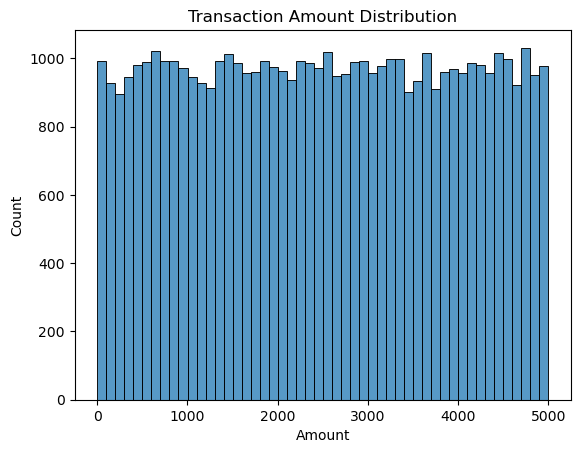

In [36]:
# Distribution of Transaction Amounts

sns.histplot(transactions['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

Index(['TransactionID', 'AccountOriginID', 'AccountDestinationID',
       'TransactionTypeID', 'Amount', 'TransactionDate', 'BranchID',
       'Description'],
      dtype='object')


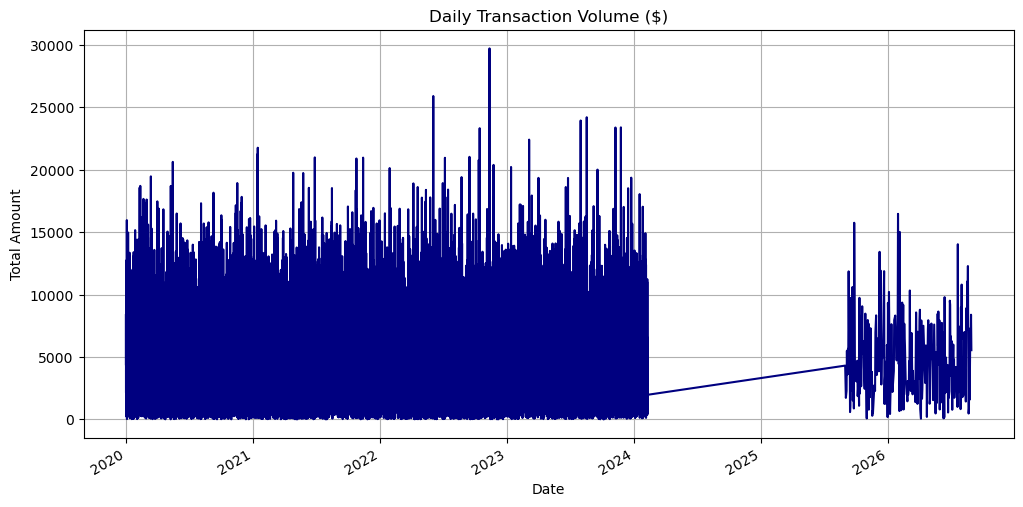

In [40]:
## Time Trend of Transactions

print(transactions.columns)
# 2. Convert to datetime using the correct name
transactions['TransactionDate'] = pd.to_datetime(transactions['TransactionDate'])
# 3. Group and Plot using the exact names
transactions.groupby('TransactionDate')['Amount'].sum().plot(figsize=(12,6), color='navy')

plt.title("Daily Transaction Volume ($)")
plt.ylabel("Total Amount")
plt.xlabel("Date")
plt.grid(True)
plt.show()

In [47]:
# Top accounts by transaction value

print(transactions.columns)
top_accounts = transactions.groupby('AccountOriginID')['Amount'].sum().sort_values(ascending=False).head(10)
# 3. Explicitly display the result
print("--- Top 10 Accounts by Total Value ---")
print(top_accounts)

Index(['TransactionID', 'AccountOriginID', 'AccountDestinationID',
       'TransactionTypeID', 'Amount', 'TransactionDate', 'BranchID',
       'Description'],
      dtype='object')
--- Top 10 Accounts by Total Value ---
AccountOriginID
200118    189169.73
200656    162500.56
200430    154667.34
201405    154569.53
201605    152235.60
200412    146062.19
200147    145599.57
201171    142763.25
201628    142238.57
201011    139129.72
Name: Amount, dtype: float64


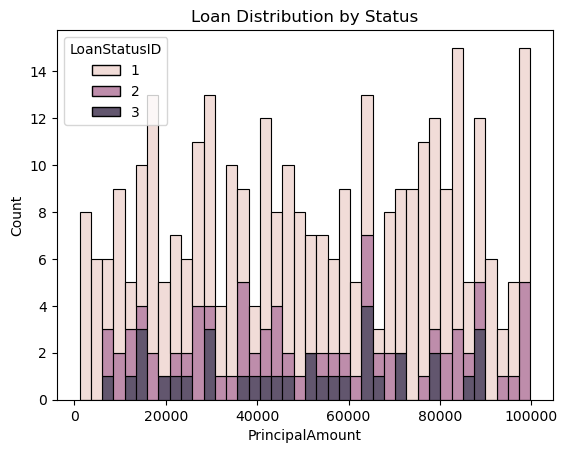

In [48]:
## Loans amount distribution

sns.histplot(data=loans, x='PrincipalAmount', bins=40, hue='LoanStatusID', multiple="stack")
plt.title("Loan Distribution by Status")
plt.show()

Overall Default Rate: 1021.02%


C:\Users\Bruger\AppData\Local\Temp\ipykernel_21780\3569207695.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='LoanStatusID', data=loans, palette='viridis')


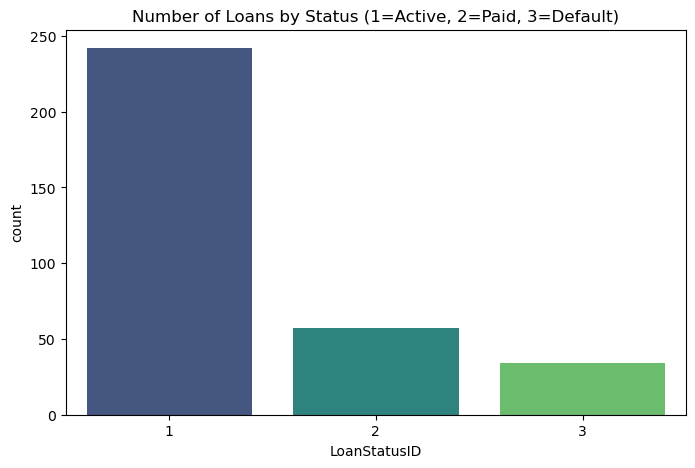

In [52]:
## Default Rate

# Calculate the percentage of loans that have defaulted
default_count = len(loans[loans['LoanStatusID'] == 3])
total_loans = len(loans)
default_rate = (default_count / total_loans) * 100
print(f"Overall Default Rate: {default_rate:.2%}")
import seaborn as sns
import matplotlib.pyplot as plt

# Visualizing Loan Status
plt.figure(figsize=(8, 5))
sns.countplot(x='LoanStatusID', data=loans, palette='viridis')
plt.title("Number of Loans by Status (1=Active, 2=Paid, 3=Default)")
plt.show()

In [55]:
## Customer Analysis,

customers.groupby('AddressID').size()
# High value customer
hvc_monetary = transactions.groupby('AccountOriginID')['Amount'].sum().sort_values(ascending=False).head(10)
print(hvc_monetary)

AccountOriginID
200118    189169.73
200656    162500.56
200430    154667.34
201405    154569.53
201605    152235.60
200412    146062.19
200147    145599.57
201171    142763.25
201628    142238.57
201011    139129.72
Name: Amount, dtype: float64


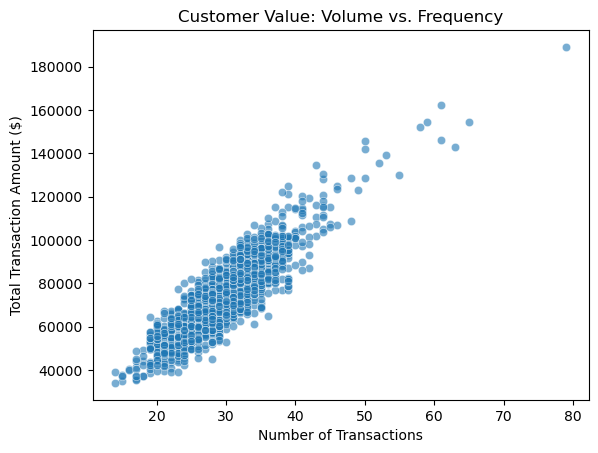

In [57]:
# Calculate both metrics
customer_stats = transactions.groupby('AccountOriginID').agg({'Amount': 'sum', 'TransactionID': 'count'})

# Plotting
sns.scatterplot(data=customer_stats, x='TransactionID', y='Amount', alpha=0.6)
plt.title("Customer Value: Volume vs. Frequency")
plt.xlabel("Number of Transactions")
plt.ylabel("Total Transaction Amount ($)")
plt.show()

In [61]:
## Fraud detection of outliers
Q1 = transactions['Amount'].quantile(0.25)
Q3 = transactions['Amount'].quantile(0.75)
IQR = Q3 - Q1

# This finds the 'Upper Fence' and 'Lower Fence'
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

# Filter the data to find ONLY the outliers
outliers = transactions[(transactions['Amount'] < lower_fence) | (transactions['Amount'] > upper_fence)]

print(f"Number of outliers detected: {len(outliers)}")
print(f"Transactions above ${upper_fence:,.2f} are considered outliers.")

Number of outliers detected: 0
Transactions above $7,492.71 are considered outliers.


In [65]:
## Flag large transactions
transactions['fraud_flag'] = transactions['Amount'] > 5000

In [68]:
## Detect sudden spikes
# 1. Calculate the 'Normal' behavior for each account
transactions['avg_amount'] = transactions.groupby('AccountOriginID')['Amount'].transform('mean')

# 2. Flag transactions that are 3x higher than that account's normal
transactions['is_spike'] = transactions['Amount'] > (3 * transactions['avg_amount'])

# 3. See how many spikes you found
print(f"Total behavioral spikes detected: {transactions['is_spike'].sum()}")

Total behavioral spikes detected: 0


In [74]:
## Accounts with many transactions in one day
daily_counts = transactions.groupby(['AccountOriginID','TransactionDate']).size()

suspicious = daily_counts[daily_counts > 5]